<a href="https://colab.research.google.com/github/yelle15/fuelcast/blob/main/GasModel2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORT MODULES AND MODELS
1. import pandas and other models

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures

# Phase 1 Data Preprocessing
1. load the dataset
2. removal of null values, replacement of null values, conversion of data types,



In [ ]:
data = pd.read_csv('/content/sea_fuel_prices_2020_2026 - Sheet1.csv')

data['date'] = pd.to_datetime(data['date'])
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day

label = LabelEncoder()
categorical_cols = ['country', 'income_level', 'subsidy_level']

for col in categorical_cols:
    data[col] = label.fit_transform(data[col])

X = data.drop(['date', 'petrol_usd_liter'], axis=1)
y = data['petrol_usd_liter']

oneScaler = StandardScaler()
X_scaled = oneScaler.fit_transform(X)

X_final = pd.DataFrame(X_scaled, columns=X.columns)
data.to_csv('cleaned_fuel_prices.csv', index=False)

data.head()
print(X_final.columns.tolist())


['country', 'income_level', 'subsidy_level', 'diesel_usd_liter', 'lpg_usd_liter', 'brent_crude_usd', 'tax_percentage', 'year', 'month', 'day']


# Phase 2 Feature Engineering
1. scaling of features (maybe use StandardScaler but it will be determined)
2. addition of features


In [ ]:
numeric_cols = ['diesel_usd_liter', 'lpg_usd_liter', 'brent_crude_usd', 'tax_percentage']

poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)

X_numeric = X[numeric_cols]
X_poly_raw = poly.fit_transform(X_numeric)

poly_feature_names = poly.get_feature_names_out(numeric_cols)
X_poly_df = pd.DataFrame(X_poly_raw, columns=poly_feature_names)

X_final_engineered = pd.concat([X.drop(numeric_cols, axis=1).reset_index(drop=True),
                                X_poly_df.reset_index(drop=True)], axis=1)
twoScaler = StandardScaler()
X_scaled_final = twoScaler.fit_transform(X_final_engineered)

X_train_ready = pd.DataFrame(X_scaled_final, columns=X_final_engineered.columns)

print(f"Original features: {X.shape[1]}")
print(f"Features after engineering: {X_train_ready.shape[1]}")
print("\nNew features include:", [col for col in X_train_ready.columns if "^2" in col or " " in col][:5])

Original features: 10
Features after engineering: 20

New features include: ['diesel_usd_liter^2', 'diesel_usd_liter lpg_usd_liter', 'diesel_usd_liter brent_crude_usd', 'diesel_usd_liter tax_percentage', 'lpg_usd_liter^2']


# Phase 3 - Descriptive Analysis and Visualization
1. frequency Distribution
2. Trends overtime
3. Categorical Comparison
4. relationships and correlations

In [ ]:
n

--- Descriptive Statistics ---
        petrol_usd_liter  diesel_usd_liter  lpg_usd_liter  brent_crude_usd  \
mean            1.774895          1.633099       1.331185       106.686453   
median          1.483000          1.345000       1.109000       112.270000   
std             1.331349          1.235538       0.999034        18.976191   
var             1.772489          1.526554       0.998068       360.095815   

        tax_percentage  
mean         21.797685  
median       19.700000  
std          15.149810  
var         229.516747  


/tmp/ipykernel_1119/35039529.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_prices.index, y=avg_prices.values, palette='viridis')


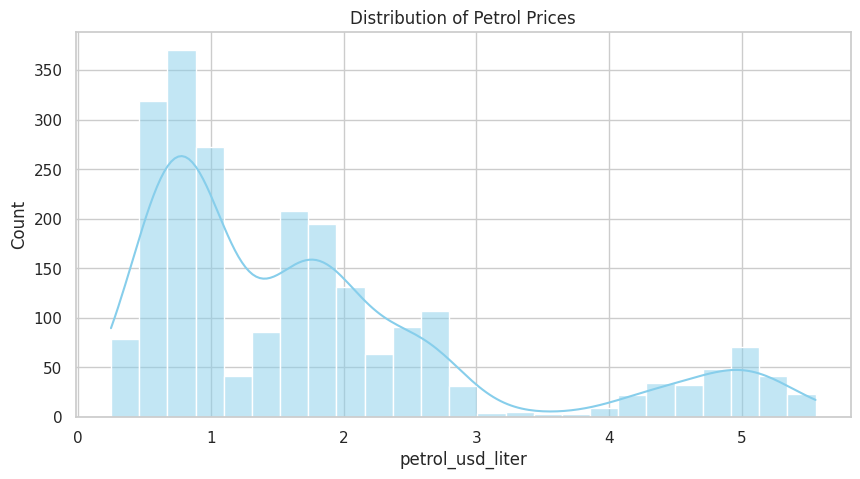

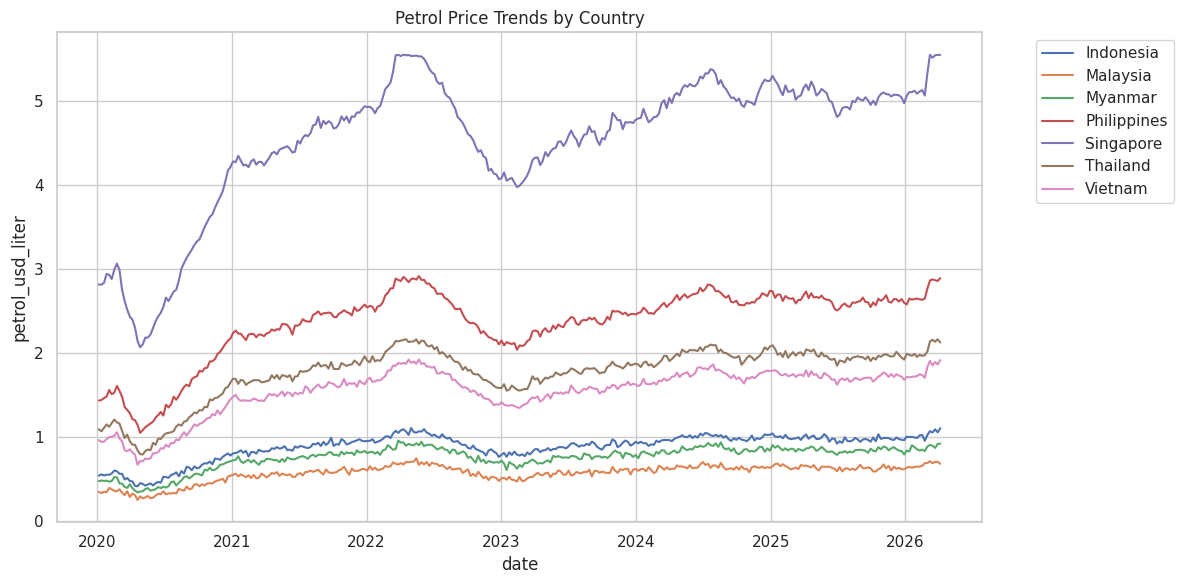

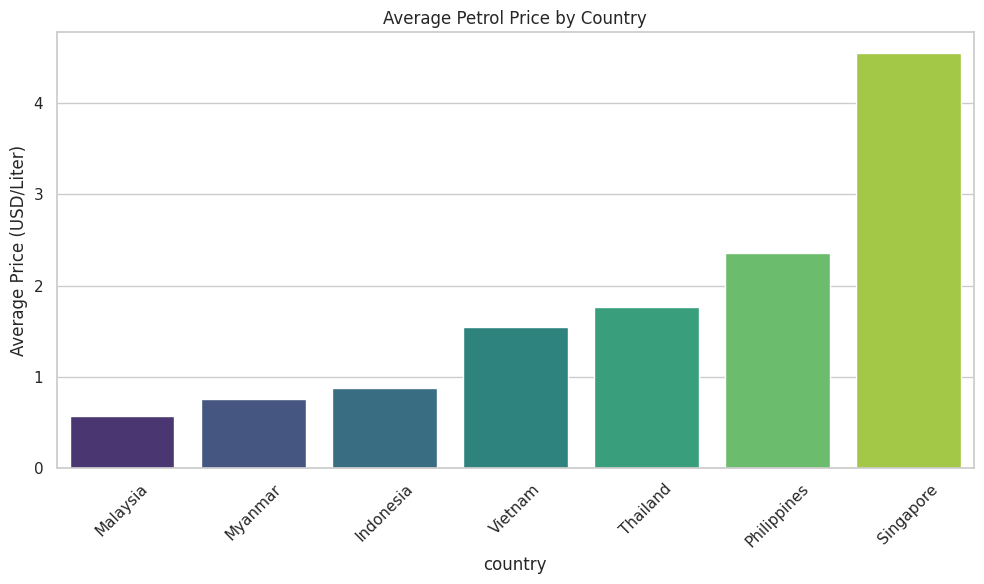

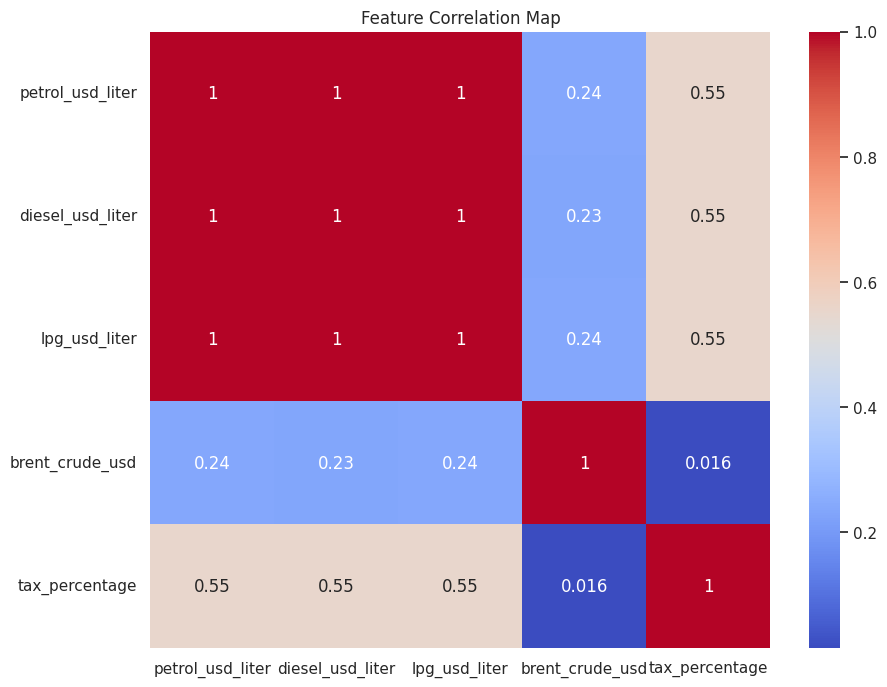

In [ ]:
df = pd.read_csv('sea_fuel_prices_2020_2026 - Sheet1.csv')
df['date'] = pd.to_datetime(df['date'])

# 2. Descriptive Analysis
numerical_cols = ['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter', 'brent_crude_usd', 'tax_percentage']
stats = df[numerical_cols].agg(['mean', 'median', 'std', 'var'])
print("--- Descriptive Statistics ---")
print(stats)

# 3. Visualizations
sns.set(style="whitegrid")

# (1) Frequency Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['petrol_usd_liter'], kde=True, color='skyblue')
plt.title('Distribution of Petrol Prices')
plt.savefig('distribution_petrol.png')

# (2) Trends over Time (Fixed with 'hue')
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='petrol_usd_liter', hue='country')
plt.title('Petrol Price Trends by Country')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('trends_over_time.png')

# (3) Categorical Comparison (NOW AS A BAR GRAPH)
plt.figure(figsize=(10, 6))
# We calculate the average price per country and sort it for a better visual
avg_prices = df.groupby('country')['petrol_usd_liter'].mean().sort_values()
sns.barplot(x=avg_prices.index, y=avg_prices.values, palette='viridis')
plt.title('Average Petrol Price by Country')
plt.ylabel('Average Price (USD/Liter)')
plt.xticks(rotation=45) # Rotates the country names
plt.tight_layout()
plt.savefig('categorical_comparison_bar.png')

# (4) Relationship and Correlations
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Map')
plt.savefig('correlation_heatmap.png')

plt.show()